# BERT-Based Sentiment Analysis

This notebook focuses on fine-tuning a BERT model for binary sentiment classification on the IMDb movie-review dataset.

The notebook covers the complete BERT fine-tuning workflow, including dataset preparation, tokenization, training configuration, model training, validation, evaluation on the held-out test set, error analysis, and sentiment prediction on new reviews.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\its0r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\its0r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Load the three spits

In [16]:

train_df = pd.read_csv("D:/NLP-Projects/sentiment-analysis-imdb/data/processed/train.csv")

validation_df = pd.read_csv("D:/NLP-Projects/sentiment-analysis-imdb/data/processed/validation.csv")

test_df = pd.read_csv("D:/NLP-Projects/sentiment-analysis-imdb/data/processed/test.csv")

In [17]:
print("Train shape:      ", train_df.shape)
print("Validation shape: ", validation_df.shape)
print("Test shape:       ", test_df.shape)

Train shape:       (35698, 7)
Validation shape:  (3967, 7)
Test shape:        (9917, 7)


### convert DataFrames to Hugging Face datasets

In [18]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["review", "sentiment"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    validation_df[["review", "sentiment"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["review", "sentiment"]],
    preserve_index=False
)

`preserve_index=False` because we don't need the pandas index as an extra dataset column

In [19]:
train_dataset

Dataset({
    features: ['review', 'sentiment'],
    num_rows: 35698
})

In [20]:
val_dataset

Dataset({
    features: ['review', 'sentiment'],
    num_rows: 3967
})

In [21]:
test_dataset

Dataset({
    features: ['review', 'sentiment'],
    num_rows: 9917
})

### Rename the label column

In [22]:
# Transformers' training workflow expects the label to be called labels.

train_dataset = train_dataset.rename_column("sentiment", "labels")
val_dataset = val_dataset.rename_column("sentiment", "labels")
test_dataset = test_dataset.rename_column("sentiment", "labels")

In [23]:
# Now sentiment has become labels
train_dataset

Dataset({
    features: ['review', 'labels'],
    num_rows: 35698
})

### Load the tokenizer

In [24]:

from transformers import AutoTokenizer

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [25]:
def tokenize_function(examples):
    return tokenizer(
        examples["review"],
        truncation=True,
        max_length=256
    )

### Tokenize the datasets

In [26]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|████████████████████████████████████████████████████████████████| 9917/9917 [00:02<00:00, 4104.52 examples/s]


In [27]:
tokenized_train

Dataset({
    features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 35698
})

### Remove the original review column

In [28]:
# BERT doesn't need the raw string once tokenization is finished.

tokenized_train = tokenized_train.remove_columns(["review"])
tokenized_val = tokenized_val.remove_columns(["review"])
tokenized_test = tokenized_test.remove_columns(["review"])

### Dynamic padding 

In [29]:

# Instead of padding every review to the maximum possible sequence length, this pads each batch to the longest sequence inside that batch.

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

### Check cuda

In [30]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce GTX 1650 Ti


### Load Bert

In [31]:

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4253.71it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

### Define training arguments

In [32]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="D:/NLP-Projects/sentiment-analysis-imdb/models/bert_imdb_80_20_split",

    num_train_epochs=2,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,

    logging_steps=100
)

In [34]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### Create Trainer

In [35]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [36]:
print(train_df.shape)
print(test_df.shape)

print(train_df["sentiment"].value_counts())
print(test_df["sentiment"].value_counts())

(35698, 7)
(9917, 7)
sentiment
1    17916
0    17782
Name: count, dtype: int64
sentiment
1    4977
0    4940
Name: count, dtype: int64


In [42]:
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA version:", torch.version.cuda)
print("Model device:", next(model.parameters()).device)
print("Trainer device:", trainer.args.device)

CUDA available: True
PyTorch CUDA version: 12.4
Model device: cuda:0
Trainer device: cuda:0


--------------------------
### ⚠️ TRAINING CELL

This cell fine-tunes BERT.

Approximate runtime:
~110 minutes on GTX 1650 Ti.

Run ONLY if you want to train the model again.

Otherwise skip this cell and load the saved model below.)

--------------------------

In [74]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.276469,0.309151,0.915553,0.895793,0.941236,0.917952
2,0.144148,0.338093,0.920847,0.918622,0.924159,0.921382


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.38s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 

TrainOutput(global_step=8926, training_loss=0.2268889560684505, metrics={'train_runtime': 6704.0386, 'train_samples_per_second': 10.65, 'train_steps_per_second': 1.331, 'total_flos': 9441575777184000.0, 'train_loss': 0.2268889560684505, 'epoch': 2.0})

#### Training Observations

- The training loss decreased substantially from **0.2765 in Epoch 1 to 0.1441 in Epoch 2**, indicating that the model continued to learn from the training data.
- Validation accuracy improved from **91.56% to 92.08%**, while validation F1 improved from **0.9180 to 0.9214**. Therefore, the model's overall classification performance improved after the second epoch.
- Validation loss increased from **0.3092 to 0.3381** even though validation accuracy and F1 improved. This indicates that the model may be becoming more confident in some of its predictions, including incorrect ones. However, with only two epochs, this alone is not enough to conclude that the model is overfitting.
- Precision increased from **0.8958 to 0.9186**, while recall decreased from **0.9412 to 0.9242**. This represents a small trade-off between precision and recall.
- Based on validation F1 and accuracy, **Epoch 2 performed better than Epoch 1** and was therefore the better checkpoint among the two.

In [50]:
test_results = trainer.predict(tokenized_test)

In [51]:
print(test_results.metrics)

{'test_loss': 0.3345925807952881, 'test_model_preparation_time': 0.0036, 'test_accuracy': 0.9248764747403448, 'test_precision': 0.9245585874799358, 'test_recall': 0.9258589511754068, 'test_f1': 0.9252083124184319, 'test_runtime': 308.4806, 'test_samples_per_second': 32.148, 'test_steps_per_second': 4.02}


In [52]:
import numpy as np
from sklearn.metrics import classification_report

predictions = np.argmax(
    test_results.predictions,
    axis=-1
)

print(
    classification_report(
        test_results.label_ids,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      4940
           1       0.92      0.93      0.93      4977

    accuracy                           0.92      9917
   macro avg       0.92      0.92      0.92      9917
weighted avg       0.92      0.92      0.92      9917



### Test Results — Observations

- The fine-tuned BERT model achieved a **test accuracy of 92.49%** and an overall **F1 score of 92.52%** on the 9,917 test reviews.
- Precision and recall were also well balanced, with **92.46% precision** and **92.59% recall**, indicating that the model performs consistently across both error types.
- The class-wise F1 scores were **0.92 for class 0** and **0.93 for class 1**, showing that the model performs similarly well for both sentiment classes.
- The weighted and macro averages are both approximately **0.92**, which further indicates that the model's performance is balanced across the two classes.
- The test loss was **0.3346**. This should not be interpreted on its own; classification metrics such as accuracy and F1 are more directly relevant to the sentiment-classification objective.
- The test set was kept separate from model training and validation-based model selection, so these results provide the final evaluation of the saved BERT model on unseen data.

### Save the Bert Model

In [83]:
model_path = "D:/NLP-Projects/sentiment-analysis-imdb/models/bert_imdb_80_20_split_final"

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print("Model saved successfully.")

Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.69s/it]

Model saved successfully.


### Load the saved Bert Model

In [45]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "D:/NLP-Projects/sentiment-analysis-imdb/models/bert_imdb_80_20_split_final"

saved_model = AutoModelForSequenceClassification.from_pretrained(model_path)
saved_tokenizer = AutoTokenizer.from_pretrained(model_path)

print("Model loaded successfully.")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4532.75it/s]

Model loaded successfully.


In [53]:
for key in trainer.model.state_dict():
    if "LayerNorm" in key:
        print(key)
        break

bert.embeddings.LayerNorm.weight


In [47]:
# Recreate the trainer and use your saved model

trainer = Trainer(
    model=saved_model,
    processing_class=saved_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [48]:
test_results = trainer.predict(tokenized_test)

In [49]:
print(test_results.metrics)

{'test_loss': 0.3345925807952881, 'test_model_preparation_time': 0.0036, 'test_accuracy': 0.9248764747403448, 'test_precision': 0.9245585874799358, 'test_recall': 0.9258589511754068, 'test_f1': 0.9252083124184319, 'test_runtime': 309.9769, 'test_samples_per_second': 31.993, 'test_steps_per_second': 4.0}


In [58]:
test_results

PredictionOutput(predictions=array([[ 4.39883  , -3.4637296],
       [-4.1954994,  3.463481 ],
       [-4.2894373,  3.5342677],
       ...,
       [-2.9731443,  2.4052784],
       [ 4.3481245, -3.4686835],
       [-4.329428 ,  3.5725088]], shape=(9917, 2), dtype=float32), label_ids=array([0, 1, 1, ..., 1, 0, 1], shape=(9917,)), metrics={'test_loss': 0.3345925807952881, 'test_model_preparation_time': 0.0036, 'test_accuracy': 0.9248764747403448, 'test_precision': 0.9245585874799358, 'test_recall': 0.9258589511754068, 'test_f1': 0.9252083124184319, 'test_runtime': 308.4806, 'test_samples_per_second': 32.148, 'test_steps_per_second': 4.02})

In [60]:
# Convert logits into predictions
import numpy as np

# Extract raw logits
logits = test_results.predictions

# Convert logits into predicted class labels
predicted_labels = np.argmax(logits, axis=1)

# Extract true labels
true_labels = test_results.label_ids

print("Logits shape:", logits.shape)
print("Predicted labels shape:", predicted_labels.shape)
print("True labels shape:", true_labels.shape)

Logits shape: (9917, 2)
Predicted labels shape: (9917,)
True labels shape: (9917,)


In [61]:
for i in range(10):
    print(
        f"Review {i}: "
        f"True = {true_labels[i]}, "
        f"Predicted = {predicted_labels[i]}, "
        f"Logits = {logits[i]}"
    )

Review 0: True = 0, Predicted = 0, Logits = [ 4.39883   -3.4637296]
Review 1: True = 1, Predicted = 1, Logits = [-4.1954994  3.463481 ]
Review 2: True = 1, Predicted = 1, Logits = [-4.2894373  3.5342677]
Review 3: True = 0, Predicted = 0, Logits = [ 3.644039 -2.869495]
Review 4: True = 0, Predicted = 0, Logits = [ 3.0799675 -2.4808903]
Review 5: True = 1, Predicted = 1, Logits = [-3.7227552  3.1183903]
Review 6: True = 0, Predicted = 0, Logits = [ 2.2388556 -1.792198 ]
Review 7: True = 0, Predicted = 0, Logits = [ 3.2859447 -2.6086822]
Review 8: True = 1, Predicted = 1, Logits = [-3.6256657  2.979587 ]
Review 9: True = 0, Predicted = 0, Logits = [ 4.401074  -3.4730191]


### Confusion Matrix

In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print(cm)

[[4564  376]
 [ 369 4608]]


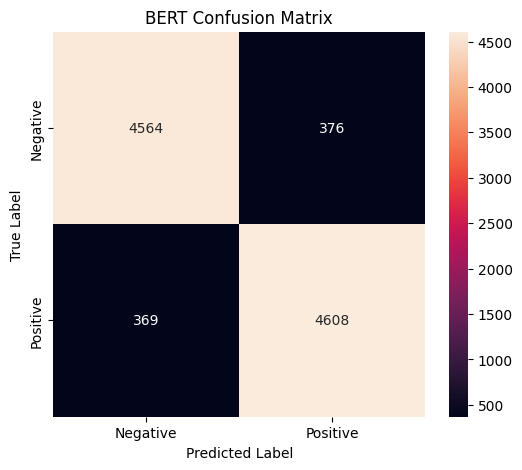

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Confusion Matrix")

plt.show()

## Confusion Matrix — Observations

- Out of **9,917 test reviews**, the model correctly classified **9,172 reviews** and incorrectly classified **745 reviews**.
- The model correctly identified **4,564 negative reviews** and **4,608 positive reviews**.
- There were **376 false positives**, where negative reviews were incorrectly classified as positive.
- There were **369 false negatives**, where positive reviews were incorrectly classified as negative.
- The number of false positives and false negatives is very similar, indicating that the model does not show a strong bias toward one type of classification error.
- There were slightly more false positives (**376**) than false negatives (**369**).
- The confusion matrix is consistent with the classification report, where the model achieved approximately **92% precision, recall, and F1 score for both classes**.
- Overall, the model correctly classified approximately **92.49%** of the test reviews, with approximately **7.51%** being misclassified.

In [64]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=["Negative", "Positive"]
)

print(report)

              precision    recall  f1-score   support

    Negative       0.93      0.92      0.92      4940
    Positive       0.92      0.93      0.93      4977

    accuracy                           0.92      9917
   macro avg       0.92      0.92      0.92      9917
weighted avg       0.92      0.92      0.92      9917



### Error Analysis

The test predictions are examined to identify patterns in incorrectly classified reviews.

The analysis focuses on:

- False Positives: negative reviews predicted as positive.
- False Negatives: positive reviews predicted as negative.
- Prediction confidence, to identify highly confident mistakes.

In [65]:
incorrect_mask = predicted_labels != true_labels

print("Incorrect predictions:", incorrect_mask.sum())
print("Correct predictions:", (~incorrect_mask).sum())

Incorrect predictions: 745
Correct predictions: 9172


In [66]:
# Retrieve the actual wrong reviews

incorrect_indices = np.where(incorrect_mask)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 745


In [69]:
label_names = {
    0: "Negative",
    1: "Positive"
}

for idx in incorrect_indices[:5]:

    print("=" * 80)

    print("Review:")
    print(test_dataset[idx]["review"])

    print("\nTrue:",
          label_names[true_labels[idx]])

    print("Predicted:",
          label_names[predicted_labels[idx]])

    print("Logits:",
          logits[idx])

Review:
The Ma & Pa Kettle characters were highly popular AND controversial. The films that featured their brood paved the way for television sitcoms that came after it and sought to emulate its winning formula. One obvious reference is 'The Beverly Hillbillies,' where the new home was bought with oil money, not having been won in a contest. You could even say the 1980s sitcom 'Newhart' borrows its idea of backwards rural characters from this series. Still, I wonder if Betty Macdonald, the Washington-based author who created these characters, didn't do more harm than good. Her portrayal of hillbilly characters makes them the butt of many jokes in terms of their alleged sloppiness and laziness. (The real life family that Macdonald based the Kettles upon, successfully sued...claiming they had been ridiculed and humiliated with these less-than-flattering references). Sure, it's comedy and the situations bring us a great many laughs and fun moments...and political correctness as we know it

#### Error Analysis — Initial Observations

- The misclassified reviews often contain **mixed or conflicting sentiment**, with both positive and negative opinions appearing in the same review.
- The model sometimes appears to be influenced by **strong sentiment-bearing phrases**, even when the overall sentiment of the review is determined by the broader context.
- These examples show that reviews with **indirect, nuanced, or mixed opinions** can be more difficult to classify than reviews with clearly expressed sentiment.
- There's another thing which is worth noticing as several reviews are huge and long and we have used **max_length = 256**. So longer reviews gets truncated and this can also give some errors.

### Effect of truncation

In [71]:
token_lengths = []

for text in test_dataset["review"]:
    tokens = tokenizer(
        text,
        truncation=False,
        add_special_tokens=True
    )["input_ids"]
    
    token_lengths.append(len(tokens))

token_lengths = np.array(token_lengths)

print("Total reviews:", len(token_lengths))
print("Reviews > 256 tokens:", np.sum(token_lengths > 256))
print(
    "Percentage > 256 tokens:",
    np.mean(token_lengths > 256) * 100
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (639 > 512). Running this sequence through the model will result in indexing errors


Total reviews: 9917
Reviews > 256 tokens: 4294
Percentage > 256 tokens: 43.29938489462539


In [72]:
truncated_mask = token_lengths > 256

incorrect_and_truncated = incorrect_mask & truncated_mask

print(
    "Incorrect predictions:",
    incorrect_mask.sum()
)

print(
    "Incorrect + truncated:",
    incorrect_and_truncated.sum()
)

print(
    "Percentage of errors involving truncation:",
    incorrect_and_truncated.sum() / incorrect_mask.sum() * 100
)

Incorrect predictions: 745
Incorrect + truncated: 439
Percentage of errors involving truncation: 58.92617449664429


In [73]:
# Error rate among truncated reviews
truncated_error_rate = (
    incorrect_mask[truncated_mask].mean() * 100
)

# Error rate among non-truncated reviews
non_truncated_error_rate = (
    incorrect_mask[~truncated_mask].mean() * 100
)

print(
    f"Error rate for reviews > 256 tokens: "
    f"{truncated_error_rate:.2f}%"
)

print(
    f"Error rate for reviews <= 256 tokens: "
    f"{non_truncated_error_rate:.2f}%"
)

Error rate for reviews > 256 tokens: 10.22%
Error rate for reviews <= 256 tokens: 5.44%


#### Effect of Truncation — Observations

- **43.30% of the test reviews exceeded the 256-token limit** and were therefore truncated before being passed to BERT.
- The error rate for reviews longer than 256 tokens was **10.22%**, compared with **5.44%** for reviews that fit within the 256-token limit.
- The error rate was therefore substantially higher among truncated reviews, suggesting that truncation may be associated with reduced classification performance on longer reviews.
- Of the **745 total incorrect predictions**, **439 (58.93%) involved reviews longer than 256 tokens**.
- These results suggest that truncation is a potential limitation of the current BERT setup, particularly for longer reviews. However, this analysis shows an **association** between review length/truncation and errors and does not by itself prove that truncation caused the errors.

### Comfident Error analysis

In [74]:
from scipy.special import softmax

probabilities = softmax(logits, axis=1)

print(probabilities[:5])

[[9.9961519e-01 3.8473945e-04]
 [4.7156570e-04 9.9952841e-01]
 [3.9997647e-04 9.9959999e-01]
 [9.9851900e-01 1.4810325e-03]
 [9.9616927e-01 3.8307456e-03]]


In [75]:
#Find confident mistakes

confidence = np.max(probabilities, axis=1)

incorrect_confidence = confidence[incorrect_mask]

In [76]:
most_confident_errors = incorrect_indices[
    np.argsort(incorrect_confidence)[::-1]
]

In [78]:
for idx in most_confident_errors[:5]:

    print("=" * 80)

    print("Review:")
    print(test_dataset[idx]["review"])

    print("\nTrue:",
          label_names[true_labels[idx]])

    print("Predicted:",
          label_names[predicted_labels[idx]])

    print("Probabilities:",
          probabilities[idx])

    print("Confidence:",
          confidence[idx])

Review:
this one of the best celebrity's reality shows a ever saw. we can see the concerts we can see the life of Britney, i love the five episodes. i was always being surprised by Britney and the subjects of the show i think that some people don't watch the show at all we can how a great person she his. she his really funny really gentle and she loves her fans and we can see how she loves her work. i just don't give a 10 because of k-fed he his a real jerk he doesn't seem to like Britney at all. I they make a second season of this great show because it shows at some people how Britney really is. Go Britney your the best and you will never leave our hearts.

True: Negative
Predicted: Positive
Probabilities: [3.2002386e-04 9.9968004e-01]
Confidence: 0.99968004
Review:
this film has it all; the deft camera work, reminiscent of martin scorcese, or oliver stone, the tight acting of 'heat', the explosive action of a jerry bruckheimer movie, the witty dialogue of a tarantino script and the e

In [79]:
confidence_thresholds = [0.50, 0.75, 0.90, 0.95, 0.99]

for threshold in confidence_thresholds:
    
    count = np.sum(
        incorrect_mask & (confidence >= threshold)
    )
    
    print(
        f"Errors with confidence >= {threshold:.2f}: "
        f"{count}"
    )

Errors with confidence >= 0.50: 745
Errors with confidence >= 0.75: 689
Errors with confidence >= 0.90: 638
Errors with confidence >= 0.95: 587
Errors with confidence >= 0.99: 363


#### High-Confidence Error Analysis — Observations

- Several misclassified reviews were **high-confidence errors**, with the model assigning approximately **99.96%–99.97% confidence** to the incorrect class.
- Some of these reviews appear to have **questionable or potentially noisy labels**. 
- Other high-confidence errors appear to be genuine **sentiment-classification challenges**, where strong positive and negative statements occur within the same review. 
- These examples suggest that some apparent model errors may be influenced not only by model limitations, but also by **ambiguity and possible inconsistencies in the dataset labels**.

### Overall Error Analysis Observation

Error analysis showed that BERT's mistakes were not homogeneous. Errors included mixed or nuanced sentiment, longer reviews affected by truncation, and several highly confident misclassifications whose assigned labels appeared questionable. This suggests that model performance is influenced not only by the model architecture and input limitations, but also by the ambiguity and quality of the underlying dataset labels.

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

final_model = final_model.to(device)
final_model.eval()

print("Device:", device)

### Sentiment Prediction on New Reviews

This section uses the saved BERT model to predict the sentiment of a new, unseen review.

The review is tokenized using the same tokenizer used during model evaluation and then passed through the trained BERT model to obtain the predicted sentiment.

In [83]:
# Put the model on the GPU
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

saved_model = saved_model.to(device)
saved_model.eval()                      # eval is important as we are into evaluation mode and not training

print("Device:", device)

Device: cuda


In [86]:
def predict_sentiment(review):

    # tokenize the review
    inputs = saved_tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    # Move inputs to the same device as the model
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Disable gradient calculation
    with torch.no_grad():

        outputs = saved_model(**inputs)

    # Get logits
    logits = outputs.logits

    # Convert logits to probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Get predicted class
    predicted_class = torch.argmax(probabilities, dim=1).item()

    # Get confidence
    confidence = probabilities[0][predicted_class].item()

    label = "Positive" if predicted_class == 1 else "Negative"

    return label, confidence

### Inference on sample reviews

In [88]:
# Passing a positive review
review = """
This movie was absolutely fantastic. The performances were brilliant,
the story was engaging, and I enjoyed every minute of it.
"""

sentiment, confidence = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Confidence:", f"{confidence:.2%}")

Sentiment: Positive
Confidence: 99.97%


In [89]:
# Passing a negative review

review = """
This film was boring. The movie lacks plot and the acting seems overacting.
I won't recommend this movie.
"""

sentiment, confidence = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Confidence:", f"{confidence:.2%}")

Sentiment: Negative
Confidence: 99.93%


In [90]:
# Passing a positive review with mixed emotions

review = """
This thing though boring at start will grab your attention in no time and shock you.
The actors have done great job and though you will hate the start but by the end you will love it.
"""

sentiment, confidence = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Confidence:", f"{confidence:.2%}")

Sentiment: Positive
Confidence: 99.90%


In [91]:
# Passing a negative sarcasm

review = """
This movie was so good that I slept watching the first half.Then after interval the movie showed peak cinema and made me sleep again.
People who have nothing to do in life will surely like this movie.
"""

sentiment, confidence = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Confidence:", f"{confidence:.2%}")

Sentiment: Positive
Confidence: 99.87%


In [98]:
# Passing a positive sarcasm

review = """
Damn the director , Damn the story and Damn the music. 
Throughout heaven and earth nothing comes closer to this shit.
This movie burst my mind. 
"""

sentiment, confidence = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Confidence:", f"{confidence:.2%}")


Sentiment: Negative
Confidence: 81.92%


In [99]:
reviews = [
    "This movie was absolutely fantastic!",
    "This movie was terrible and completely boring.",
    "The movie was not bad.",
    "The movie was good but the ending was disappointing.",
    "What a masterpiece. I fell asleep halfway through.",
]
for review in reviews:
    sentiment, confidence = predict_sentiment(review)
    print("review:", review)
    print("Sentiment:", sentiment)
    print("Confidence:", f"{confidence:.2%}")
    print("\n")

review: This movie was absolutely fantastic!
Sentiment: Positive
Confidence: 99.94%


review: This movie was terrible and completely boring.
Sentiment: Negative
Confidence: 99.96%


review: The movie was not bad.
Sentiment: Positive
Confidence: 63.55%


review: The movie was good but the ending was disappointing.
Sentiment: Negative
Confidence: 98.37%


review: What a masterpiece. I fell asleep halfway through.
Sentiment: Positive
Confidence: 99.60%




#### Observations

- The model correctly identifies a clearly negative review and a positive review containing some negative language, both with very high confidence.
- The model struggles with **sarcasm and ironic expressions**. In the negative sarcastic example, strongly positive words such as "so good" appear in a clearly negative context, leading to an incorrect prediction with **99.87% confidence**.
- The second sarcastic example was also challenging: the model predicted negative with **81.92% confidence**, showing that sarcastic language can produce uncertainty or misleading sentiment signals.
- These examples demonstrate that high confidence does not always guarantee a correct prediction, particularly when the intended sentiment differs from the literal wording.

### Save the BERT results Dataframe

In [100]:
bert_test_results = pd.DataFrame([
    {
        "representation": "BERT",
        "configuration": "Fine-tuned BERT, max_length=256, epochs=2",
        "classifier": "BERT classification head",
        "accuracy": test_results.metrics["test_accuracy"],
        "precision": test_results.metrics["test_precision"],
        "recall": test_results.metrics["test_recall"],
        "f1": test_results.metrics["test_f1"]
    }
])

bert_test_results

,representation,configuration,classifier,accuracy,precision,recall,f1
0,BERT,"Fine-tuned BERT, max_length=256, epochs=2",BERT classification head,0.924876,0.924559,0.925859,0.925208


In [101]:
bert_test_results.to_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/results/bert_results.csv",
    index=False
)

## Final Experiment Notes

- The dataset was divided into a **72% training, 8% validation, and 20% test split**. The same fixed split was used throughout the project so that the different models could be compared fairly.

- BERT was fine-tuned using the **training set**, while the validation set was evaluated during training to monitor the model's performance and determine the better-performing epoch.

- The training configuration was defined using Hugging Face **`TrainingArguments`**, which specified the main training settings such as the number of epochs, batch sizes, evaluation and logging behaviour.

- Hugging Face **`Trainer`** was used to manage the training and evaluation process. It handled the training loop, validation evaluation, metric calculation, and interaction between the model, tokenizer, and datasets.

- **CUDA/GPU acceleration** was used during training when available, allowing the computationally intensive BERT fine-tuning process to run on the GPU.

- The model used the **original review text** rather than the cleaned text used for the classical NLP models. Reviews were tokenized with `truncation=True` and a maximum sequence length of **256 tokens**.

- After model selection, the saved BERT model was evaluated once on the **20% held-out test set**. The training and validation sets were not combined before this evaluation.

- The final model achieved **92.49% test accuracy and 92.52% test F1**, with balanced precision and recall across the positive and negative classes.

- A **confusion matrix and error analysis** were performed to examine the types of mistakes made by the model, including mixed sentiment, nuanced language, sarcasm, and potentially questionable dataset labels.